In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Question 9

In [3]:
# generate data
e = np.random.normal(0, 1, 20)
x = np.random.uniform(0, (2*np.pi), 20)
y_original = np.sin(x) + e

# phi_x - n*5 matrix
phi_x = np.array([np.ones(len(x)), x, x**2, x**3, x**4]).T
# y - n*1 matrix
y = np.array([y_original]).T

# sigma2 and tau2 - assume known
sigma2 = 0.2
tau2 = 0.5
l = sigma2 / tau2

# MLE - for pluggin estimate - 5*1 matrix
# MLE for weight
weight_MLE = np.dot(np.dot(np.linalg.inv(np.dot(phi_x.T, phi_x)), phi_x.T), y)

# mean and covariance for posterior distribution of weight
i_d = np.diag(np.ones(len(weight_MLE)))
w_n = np.dot(np.dot(np.linalg.inv(l * i_d + np.dot(phi_x.T, phi_x)), phi_x.T), y)
v_n = sigma2 * np.linalg.inv(l * i_d + np.dot(phi_x.T, phi_x))

[[-3.91509191]
 [ 5.99453081]
 [-2.56887943]
 [ 0.40282769]
 [-0.02048408]]


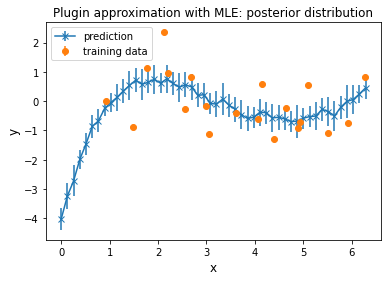

In [7]:
# plot a
# for plugin estimation with MLE
grid = np.linspace(0, (2*np.pi), 50)
phi_x_test = np.array([np.ones(len(grid)), grid, grid**2, grid**3, grid**4]).T
y_pred = [[] for i in range(50)]
for i in range(len(phi_x_test)):
    x_test_i = np.array([phi_x_test[i]])
    mean_i = np.dot(x_test_i, weight_MLE)[0][0]
    scale_i = sigma2 ** 0.5
    y_pred_i = np.random.normal(mean_i, scale_i, 20)
    y_pred[i].extend(list(y_pred_i))
y_pred = np.array(y_pred)
y_pred_mean = np.mean(y_pred, axis=1)
y_pred_std = np.std(y_pred, axis=1)

plt.errorbar(grid, y_pred_mean, yerr = y_pred_std, marker = 'x')
plt.errorbar(x, y_original, yerr = np.zeros(len(x)), fmt='o')
plt.xlabel(r"x", fontsize = 12)
plt.ylabel(r"y", fontsize = 12)
plt.title("Plugin approximation with MLE: posterior distribution")
plt.legend(labels=["prediction", "training data"], loc=2)
plt.show()

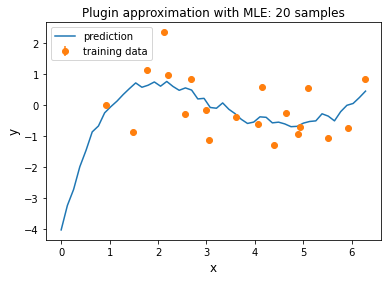

In [8]:
# plot c
plt.plot(grid, y_pred_mean)
plt.errorbar(x, y_original, yerr = np.zeros(len(x)), fmt='o')
plt.xlabel(r"x", fontsize = 12)
plt.ylabel(r"y", fontsize = 12)
plt.title("Plugin approximation with MLE: 20 samples")
plt.legend(labels=["prediction", "training data"], loc=2)
plt.show()

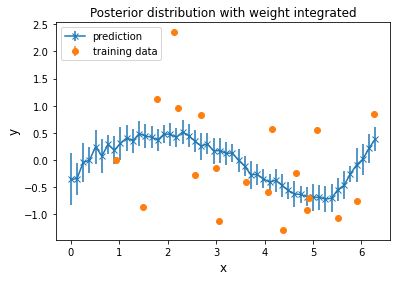

In [9]:
# plot b
# integrated out weight and get posterior
# mean and covariance for posterior distribution of Y
# phi_x_test - 1*5 matrix
mean_pos = np.dot(phi_x_test, w_n)
var_pos = sigma2 + np.dot(np.dot(phi_x_test, v_n), phi_x_test.T)
y_pred = [[] for i in range(50)]
for i in range(len(phi_x_test)):
    x_test_i = np.array([phi_x_test[i]])
    mean_i = np.dot(x_test_i, w_n)[0][0]
    scale_i = sigma2 + np.dot(np.dot(x_test_i, v_n), x_test_i.T)[0][0]
    y_pred_i = np.random.normal(mean_i, scale_i, 20)
    y_pred[i].extend(list(y_pred_i))
y_pred = np.array(y_pred)
y_pred_mean = np.mean(y_pred, axis=1)
y_pred_std = np.std(y_pred, axis=1)

plt.errorbar(grid, y_pred_mean, yerr = y_pred_std, marker = 'x')
plt.errorbar(x, y_original, yerr = np.zeros(len(x)), fmt='o')
plt.xlabel(r"x", fontsize = 12)
plt.ylabel(r"y", fontsize = 12)
plt.title("Posterior distribution with weight integrated")
plt.legend(labels=["prediction", "training data"], loc=2)
plt.show()

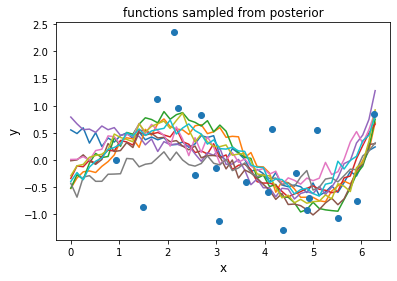

In [10]:
# plot d
# sample weights from its posterior
for d in range(10):
    weight_d = np.random.multivariate_normal(w_n.T[0], v_n, 1).T
    y_pred = [[] for i in range(50)]
    for i in range(len(phi_x_test)):
        x_test_i = np.array([phi_x_test[i]])
        mean_i = np.dot(x_test_i, weight_d)[0][0]
        scale_i = sigma2 ** 0.5
        y_pred_i = np.random.normal(mean_i, scale_i, 20)
        y_pred[i].extend(list(y_pred_i))

    y_pred = np.array(y_pred)
    y_pred_mean = np.mean(y_pred, axis=1)
    #y_pred_std = np.std(y_pred, axis=1)
    plt.plot(grid, y_pred_mean)

plt.errorbar(x, y_original, yerr = np.zeros(len(x)), fmt='o')
plt.xlabel(r"x", fontsize = 12)
plt.ylabel(r"y", fontsize = 12)
plt.title("functions sampled from posterior")
plt.show()